# Лабораторная работа №7

## Баканов Сергей ИБМ3-65Б

In [101]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.preprocessing import MinMaxScaler

from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima

from gplearn.genetic import SymbolicRegressor

plt.style.use('seaborn-v0_8')

In [85]:
df = pd.read_csv("gold.csv")
df.head()

,date,adj close,close,high,low,open,volume,ma_7,ma_30,ma_90,daily_return,volatility_7,volatility_30,rsi,macd,macd_signal,bb_upper,bb_lower
0,2021-06-11,1877.400024,1877.400024,1902.300049,1875.199951,1900.900024,349,1887.828561,1860.180005,1790.618891,-0.008869,0.009353,0.007538,54.722931,19.724030,24.933953,1918.242879,1853.797124
1,2021-06-14,1864.000000,1864.000000,1866.599976,1846.500000,1866.199951,41,1886.799997,1863.403337,1790.972225,-0.007138,0.006411,0.007711,49.391919,16.433420,23.233846,1913.119794,1861.530206
2,2021-06-15,1854.500000,1854.500000,1867.199951,1854.400024,1866.400024,78,1881.757132,1865.506669,1791.701114,-0.005097,0.004572,0.007474,45.972581,12.910196,21.169116,1914.969370,1858.380630
3,2021-06-16,1859.500000,1859.500000,1860.099976,1809.199951,1859.400024,117,1876.428554,1868.296667,1792.241113,0.002696,0.004348,0.007240,48.012515,10.401571,19.015607,1915.862799,1856.657196
4,2021-06-17,1773.800049,1773.800049,1823.300049,1769.599976,1811.800049,1135,1859.514282,1867.953337,1791.595558,-0.046088,0.016895,0.011288,28.293542,1.481124,15.508710,1938.202457,1823.567538


In [86]:
df['date'] = pd.to_datetime(df['date'])

df = df.sort_values('date')

df.set_index('date', inplace=True)

series = df['close']

series.head()

date
2021-06-11    1877.400024
2021-06-14    1864.000000
2021-06-15    1854.500000
2021-06-16    1859.500000
2021-06-17    1773.800049
Name: close, dtype: float64

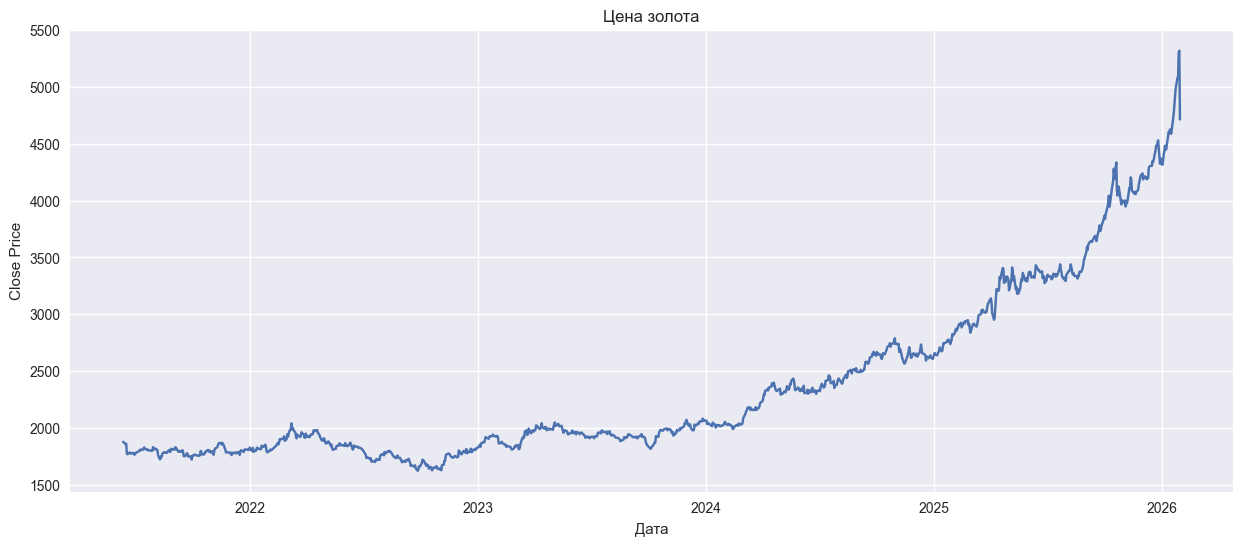

In [87]:
plt.figure(figsize=(15,6))

plt.plot(
    series.index,
    series.values
)

plt.title('Цена золота')

plt.xlabel('Дата')

plt.ylabel('Close Price')

plt.show()

In [88]:
series.describe()

count    1167.000000
mean     2363.105823
std       749.127289
min      1623.300049
25%      1827.299988
50%      1985.900024
75%      2666.099976
max      5318.399902
Name: close, dtype: float64

In [105]:
# Блок 7. Формирование train/test

target = 'close'

features = [
    'open',
    'high',
    'low',
    'volume',
    'ma_7',
    'ma_30',
    'ma_90',
    'daily_return',
    'volatility_7',
    'volatility_30',
    'rsi',
    'macd',
    'macd_signal',
    'bb_upper',
    'bb_lower'
]

X = df[features]

y = df[target]

train_size = int(len(df) * 0.8)

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

In [106]:
# Блок 8. SARIMAX

from statsmodels.tsa.statespace.sarimax import SARIMAX

sarimax_model = SARIMAX(
    endog=y_train,
    exog=X_train,
    order=(2,1,2),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_fit = sarimax_model.fit(
    disp=False
)

sarimax_forecast = sarimax_fit.predict(
    start=len(y_train),
    end=len(y_train) + len(y_test) - 1,
    exog=X_test
)

print(sarimax_forecast[:5])

933    2887.061163
934    2846.643020
935    2883.756967
936    2898.418693
937    2905.488843
Name: predicted_mean, dtype: float64


In [91]:
MAX_LAG = 10

def make_lag_features(
    series,
    lags=10
):

    data = {
        'target': series.values
    }

    for lag in range(
        1,
        lags + 1
    ):

        data[f'lag_{lag}'] = np.roll(
            series.values,
            lag
        )

    lag_df = pd.DataFrame(data)

    lag_df = lag_df.iloc[lags:]

    X = lag_df.drop(
        columns=['target']
    )

    y = lag_df['target']

    return X, y

In [112]:
from gplearn.genetic import SymbolicRegressor

sr_model = SymbolicRegressor(
    population_size=1000,
    generations=30,
    stopping_criteria=0.01,
    random_state=42,
    verbose=1
)

sr_model.fit(
    X_train,
    y_train
)

sr_forecast = sr_model.predict(
    X_test
)

print(len(sr_forecast))

    |   Population Average    |             Best Individual              |
---- ------------------------- ------------------------------------------ ----------
 Gen   Length          Fitness   Length          Fitness      OOB Fitness  Time Left
   0    23.50      6.78205e+27        3          8.94311              N/A     29.10s
   1     5.76      3.37406e+07        7          8.51166              N/A     22.26s
   2     4.01          941.496        7          8.43496              N/A     20.12s
   3     6.15           675.77       11          8.03654              N/A     21.12s
   4     8.78          2535.19       13          7.63715              N/A     19.56s
   5    12.50          1761.53       37          7.53075              N/A     20.05s
   6    16.43          1476.09       31          7.52229              N/A     20.65s
   7    19.98          4940.87       25          7.52091              N/A     18.74s
   8    19.05            78359       29          7.51941              N/A  

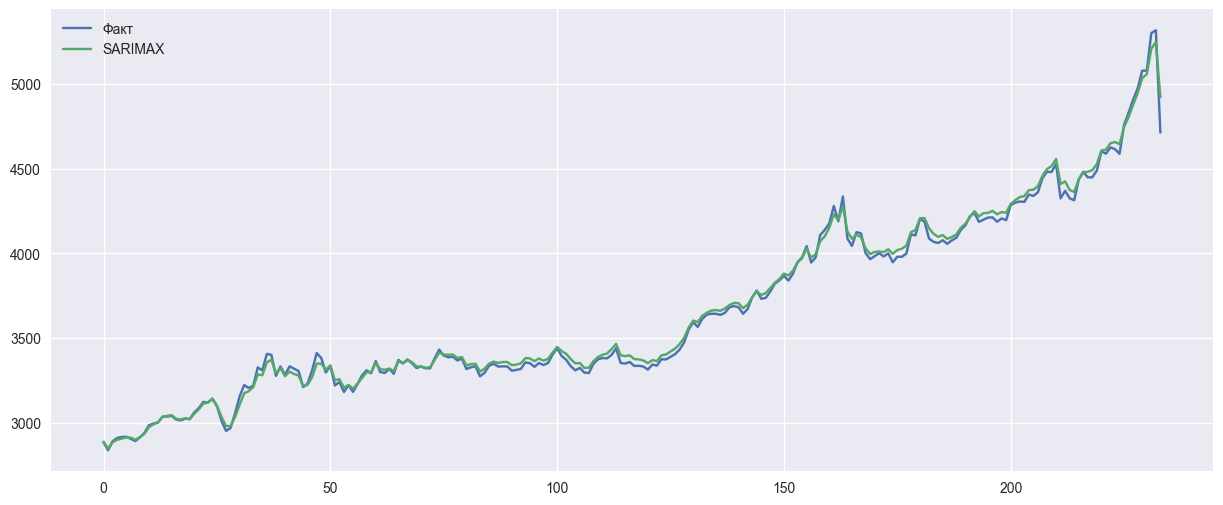

In [118]:
plt.figure(figsize=(15,6))

plt.plot(
    y_test.values,
    label='Факт'
)

plt.plot(
    np.array(sarimax_forecast),
    label='SARIMAX'
)

plt.legend()
plt.show()

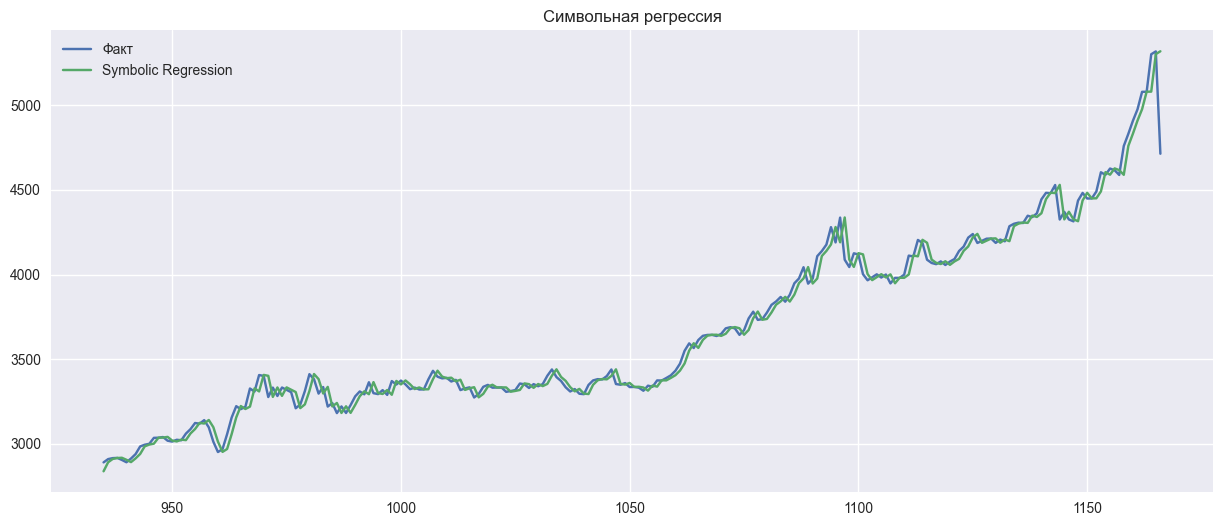

In [94]:
plt.figure(figsize=(15,6))

plt.plot(
    y_test_sr.index,
    y_test_sr.values,
    label='Факт'
)

plt.plot(
    y_test_sr.index,
    sr_forecast,
    label='Symbolic Regression'
)

plt.legend()

plt.title(
    'Символьная регрессия'
)

plt.show()

In [95]:
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred)/ y_true)) * 100

In [96]:
arima_mae = mean_absolute_error(
    test,
    arima_forecast
)

arima_mse = mean_squared_error(
    test,
    arima_forecast
)

arima_rmse = np.sqrt(
    arima_mse
)

arima_r2 = r2_score(
    test,
    arima_forecast
)

arima_mape = mape(
    test,
    arima_forecast
)

In [97]:
sr_mae = mean_absolute_error(
    y_test_sr,
    sr_forecast
)

sr_mse = mean_squared_error(
    y_test_sr,
    sr_forecast
)

sr_rmse = np.sqrt(
    sr_mse
)

sr_r2 = r2_score(
    y_test_sr,
    sr_forecast
)

sr_mape = mape(
    y_test_sr,
    sr_forecast
)

In [98]:
results = pd.DataFrame({

    'MAE': [
        arima_mae,
        sr_mae
    ],

    'MSE': [
        arima_mse,
        sr_mse
    ],

    'RMSE': [
        arima_rmse,
        sr_rmse
    ],

    'R²': [
        arima_r2,
        sr_r2
    ],

    'MAPE': [
        arima_mape,
        sr_mape
    ]

},

index=[
    'ARIMA',
    'Symbolic Regression'
])

results

,MAE,MSE,RMSE,R²,MAPE
ARIMA,749.305842,842084.507144,917.651626,-1.977847,NaN
Symbolic Regression,40.431862,4490.415305,67.010561,0.983941,1.071337


In [107]:
from gmdhpy import gmdh

In [108]:
combi_model = gmdh.MultilayerGMDH(
    ref_functions=gmdh.RefFunctionType.rfLinear
)

combi_model.fit(
    X_train.values,
    y_train.values
)

combi_forecast = combi_model.predict(
    X_test.values
)

train layer0 in 0.30 sec
train layer1 in 1.31 sec
train layer2 in 1.20 sec
train layer3 in 1.23 sec
train layer4 in 1.18 sec
train layer5 in 1.26 sec
train layer6 in 1.16 sec
train layer7 in 1.20 sec


In [109]:
mia_model = gmdh.MultilayerGMDH(

    ref_functions=(

        gmdh.RefFunctionType.rfLinearCov,

        gmdh.RefFunctionType.rfQuadratic,

        gmdh.RefFunctionType.rfCubic

    )
)

mia_model.fit(
    X_train.values,
    y_train.values
)

mia_forecast = mia_model.predict(
    X_test.values
)

train layer0 in 1.61 sec
train layer1 in 6.24 sec
train layer2 in 6.53 sec
train layer3 in 5.86 sec
train layer4 in 6.47 sec
train layer5 in 6.19 sec
train layer6 in 6.65 sec
train layer7 in 5.94 sec
train layer8 in 5.67 sec
train layer9 in 5.76 sec
train layer10 in 6.03 sec
train layer11 in 5.98 sec
train layer12 in 5.72 sec
train layer13 in 5.77 sec
train layer14 in 6.01 sec


In [113]:
results = {}

for name, pred in {

    'SARIMAX': sarimax_forecast,
    'Symbolic Regression': sr_forecast,
    'COMBI': combi_forecast,
    'MIA': mia_forecast

}.items():

    results[name] = {

        'MAE': mean_absolute_error(
            y_test,
            pred
        ),

        'MSE': mean_squared_error(
            y_test,
            pred
        ),

        'RMSE': np.sqrt(
            mean_squared_error(
                y_test,
                pred
            )
        ),

        'R²': r2_score(
            y_test,
            pred
        )
    }

results = pd.DataFrame(results).T

results

,MAE,MSE,RMSE,R²
SARIMAX,23.772624,961.121606,31.001961,0.996601
Symbolic Regression,20.957149,931.466247,30.519932,0.996706
COMBI,11.046788,491.688528,22.174051,0.998261
MIA,15.509619,516.265092,22.721468,0.998174
